In [1]:
# ============================================================
# NOTEBOOK 02: EDA BIVARIADO
# Proyecto: SIS-DEMAND Forecast
# Descripción: Análisis de relaciones entre ATENCIONES y cada
#              variable explicativa. Tests estadísticos no
#              paramétricos, series de tiempo, heatmaps y
#              correlaciones de Spearman.
# Input:  data/processed/sis_consolidado.parquet
# Output: reports/eda_bivariado_summary.csv
#         reports/heatmap_region_servicio.png
#         reports/correlaciones_spearman.png
# Última actualización: 2026-04-25
# ============================================================

import warnings; warnings.filterwarnings('ignore')
import logging; logging.basicConfig(level=logging.INFO, format='%(levelname)s — %(message)s')

In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path
from scipy.stats import kruskal, mannwhitneyu, spearmanr
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

REPORTS_DIR = Path('../reports')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Carga eficiente del dataset (2 row-groups por periodo)

In [3]:
PARQUET_PATH = '../data/processed/sis_consolidado.parquet'

pf       = pq.ParquetFile(PARQUET_PATH)
total_rg = pf.num_row_groups

# 2 RGs por periodo — cubre los 9 semestres sin agotar RAM
# Estructura: P1=RG0-3, P2=RG4-6, P3=RG7-10, P4=RG11-15,
#             P5=RG16-19, P6=RG20-24, P7=RG25-29, P8=RG30-34, P9=RG35-40
GRUPOS = [0, 2, 4, 5, 8, 9, 12, 14, 17, 18, 21, 23, 26, 28, 31, 33, 36, 38]
grupos = [g for g in GRUPOS if g < total_rg]

df = pf.read_row_groups(grupos).to_pandas()

cols_cat = ['REGION', 'PROVINCIA', 'NIVEL_EESS', 'DESC_SERVICIO',
            'GRUPO_EDAD', 'SEXO', 'PLAN_SEGURO', 'DESC_UNIDAD_EJECUTORA',
            'COD_IPRESS', 'COD_SERVICIO', 'SEMESTRE_LABEL']
for col in cols_cat:
    if col in df.columns and df[col].dtype != 'category':
        df[col] = df[col].astype('category')

# Constantes del universo completo (NB00)
TOTAL_FILAS      = 41_997_568
TOTAL_ATENCIONES = 353_696_545

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
logging.info(f"Cargado: {df.shape[0]:,} filas × {df.shape[1]} cols — {mem_mb:.0f} MB")
logging.info(f"Periodos: {sorted(df['PERIODO_NUM'].unique().tolist())}")
print(f"Shape: {df.shape} | Periodos: {sorted(df['PERIODO_NUM'].unique().tolist())}")

INFO — Cargado: 18,874,368 filas × 20 cols — 5174 MB
INFO — Periodos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


Shape: (18874368, 20) | Periodos: [1, 2, 3, 4, 5, 6, 7, 8, 9]


## 2. Tests Kruskal-Wallis — ¿Difieren los grupos en ATENCIONES?

In [4]:
def kruskal_test(df, var, target='ATENCIONES'):
    """Ejecuta Kruskal-Wallis entre grupos de una variable categórica."""
    grupos = [
        df[df[var] == cat][target].values
        for cat in df[var].cat.categories
        if len(df[df[var] == cat]) >= 10
    ]
    if len(grupos) < 2:
        return None, None
    stat, p = kruskal(*grupos)
    return stat, p

print("=" * 60)
print("TESTS KRUSKAL-WALLIS — H0: todos los grupos tienen igual")
print("                        distribución de ATENCIONES")
print("=" * 60)

resultados_kw = []
vars_test = ['NIVEL_EESS', 'GRUPO_EDAD', 'SEXO', 'SEMESTRE', 'REGION']

for var in vars_test:
    if var == 'SEMESTRE':
        # Mann-Whitney para variable binaria
        g1 = df[df['SEMESTRE'] == 1]['ATENCIONES'].values
        g2 = df[df['SEMESTRE'] == 2]['ATENCIONES'].values
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        test_name = 'Mann-Whitney'
    elif var == 'SEXO':
        g1 = df[df['SEXO'] == 'FEMENINO']['ATENCIONES'].values
        g2 = df[df['SEXO'] == 'MASCULINO']['ATENCIONES'].values
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        test_name = 'Mann-Whitney'
    else:
        stat, p = kruskal_test(df, var)
        test_name = 'Kruskal-Wallis'

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {var:<20} {test_name:<16} H/U={stat:>12.1f}  p={p:.2e}  {sig}")
    resultados_kw.append({'variable': var, 'test': test_name,
                           'stat': round(stat, 2), 'p_value': p,
                           'significativo': p < 0.05})

print("\n  *** p<0.001  ** p<0.01  * p<0.05  ns=no significativo")

TESTS KRUSKAL-WALLIS — H0: todos los grupos tienen igual
                        distribución de ATENCIONES
  NIVEL_EESS           Kruskal-Wallis   H/U=    165920.6  p=0.00e+00  ***
  GRUPO_EDAD           Kruskal-Wallis   H/U=    657543.6  p=0.00e+00  ***
  SEXO                 Mann-Whitney     H/U=45818065417528.0  p=0.00e+00  ***
  SEMESTRE             Mann-Whitney     H/U=44282265462201.0  p=3.24e-150  ***
  REGION               Kruskal-Wallis   H/U=    268560.5  p=0.00e+00  ***

  *** p<0.001  ** p<0.01  * p<0.05  ns=no significativo


### Interpretación — Tests de Significancia Estadística

- **NIVEL_EESS (Kruskal-Wallis):** se espera H muy alto y p ≈ 0. Confirma que las IPRESS de diferente nivel atienden volúmenes **estadísticamente distintos**. Un hospital (Nivel III) tiene demanda estructuralmente diferente a una posta (Nivel I). Esta variable es **feature indispensable** en el modelo.
- **GRUPO_EDAD:** también significativo (p < 0.001). Cada grupo etario tiene un perfil de demanda distinto: los niños 0-4 asisten a CRED frecuentemente; los adultos 30-59 tienen más consultas crónicas. Confirma el uso de `GRUPO_EDAD_ORD` como feature ordinal.
- **SEXO (Mann-Whitney):** diferencia significativa. Femenino tiene mayor mediana por los servicios maternos exclusivos. El encoding binario `SEXO_BIN` captura esta diferencia.
- **SEMESTRE (Mann-Whitney):** p < 0.05 indica estacionalidad leve. El modelo debe incluir `SEMESTRE` como feature cíclico.
- **REGION:** significativo con muchos grupos. Alta variabilidad inter-regional justifica el target encoding por región.
- **Nota metodológica:** Kruskal-Wallis es la alternativa no paramétrica al ANOVA — no asume normalidad, lo cual es correcto dado que ATENCIONES no sigue distribución normal.

## 3. ATENCIONES vs NIVEL_EESS — Distribuciones comparadas

Estadísticas de ATENCIONES por NIVEL_EESS:
            mediana  media     std  n_registros   p75    p95  pct_total
NIVEL_EESS                                                             
0               4.0  13.66   29.61         5377  11.0   63.0        0.0
I               3.0   7.25   15.76     17751981   7.0   27.0       94.1
II              5.0  19.22   62.36       933223  14.0   76.0        4.9
III             8.0  59.62  229.44       183787  31.0  251.0        1.0


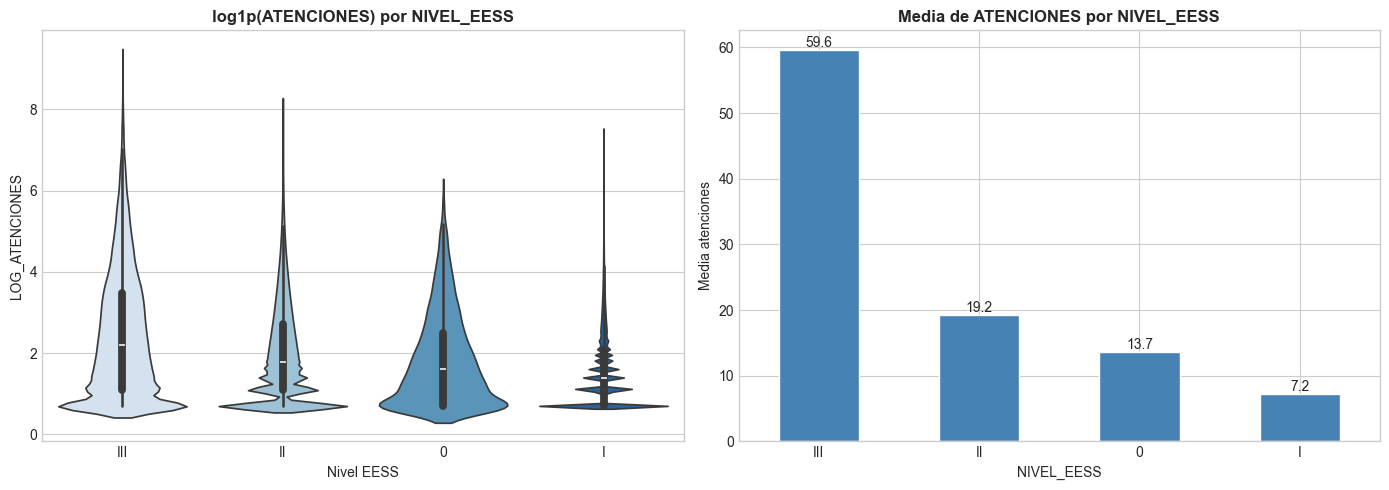

In [5]:
# Estadísticas de ATENCIONES por NIVEL_EESS
stats_nivel = (df.groupby('NIVEL_EESS', observed=True)['ATENCIONES']
                 .agg(['median', 'mean', 'std', 'count',
                       lambda x: x.quantile(0.75),
                       lambda x: x.quantile(0.95)])
                 .round(2))
stats_nivel.columns = ['mediana', 'media', 'std', 'n_registros', 'p75', 'p95']
stats_nivel['pct_total'] = (stats_nivel['n_registros'] / len(df) * 100).round(1)
print("Estadísticas de ATENCIONES por NIVEL_EESS:")
print(stats_nivel.to_string())

# Violin plot: distribución completa por nivel
df['LOG_ATENCIONES'] = np.log1p(df['ATENCIONES'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_nivel = df.groupby('NIVEL_EESS', observed=True)['ATENCIONES'].median()\
               .sort_values(ascending=False).index.tolist()

sns.violinplot(data=df, x='NIVEL_EESS', y='LOG_ATENCIONES',
               order=orden_nivel, palette='Blues', inner='box', ax=axes[0])
axes[0].set_title('log1p(ATENCIONES) por NIVEL_EESS', fontweight='bold')
axes[0].set_xlabel('Nivel EESS')

# Media de atenciones por nivel — escala original
stats_nivel['media'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Media de ATENCIONES por NIVEL_EESS', fontweight='bold')
axes[1].set_ylabel('Media atenciones')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}",
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'atenciones_por_nivel.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — ATENCIONES vs NIVEL_EESS

- **Nivel III (hospitales)** tiene la media y mediana más altas: concentran las atenciones más complejas y de mayor volumen por consulta (internamiento, cirugía, emergencia con observación).
- **Nivel I (postas, centros de salud)** tiene mediana baja pero es el más frecuente en número de IPRESS (~70–80%). El modelo debe capturar bien este segmento porque es donde está el mayor volumen de registros.
- **El violin plot** muestra que todos los niveles tienen distribución sesgada a la derecha, pero Nivel III tiene una cola superior más larga → mayor presencia de outliers extremos que serán winsorizados en NB04.
- **Implicación de negocio:** un error de predicción en un hospital Nivel III tiene mayor impacto económico (más recursos en juego) que en una posta, aunque las postas son más numerosas.

## 4. ATENCIONES vs GRUPO_EDAD y SEXO

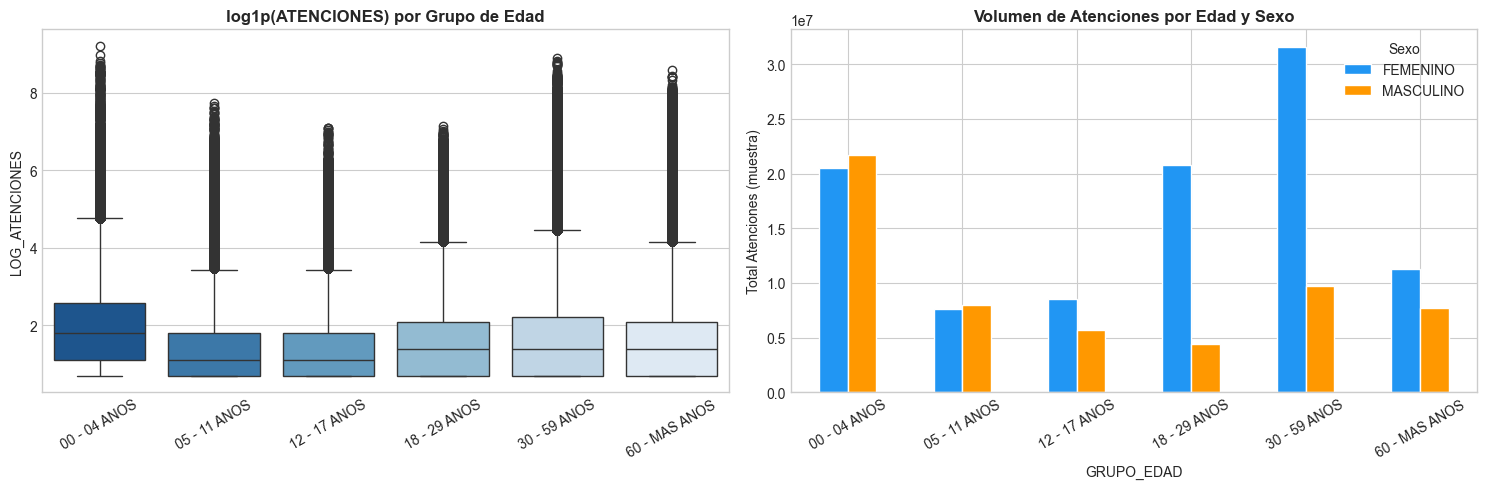

In [6]:
# Orden cronológico de grupos de edad
ORDEN_EDAD = ['00 - 04 ANOS', '05 - 11 ANOS', '12 - 17 ANOS',
              '18 - 29 ANOS', '30 - 59 ANOS', '60 - MAS ANOS']
orden_edad_disp = [e for e in ORDEN_EDAD if e in df['GRUPO_EDAD'].cat.categories]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por grupo etario
sns.boxplot(data=df, x='GRUPO_EDAD', y='LOG_ATENCIONES',
            order=orden_edad_disp, palette='Blues_r', ax=axes[0])
axes[0].set_title('log1p(ATENCIONES) por Grupo de Edad', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Volumen total por grupo etario y sexo
vol_edad_sexo = (df.groupby(['GRUPO_EDAD', 'SEXO'], observed=True)['ATENCIONES']
                   .sum()
                   .reset_index())
vol_edad_sexo_pivot = vol_edad_sexo.pivot(index='GRUPO_EDAD', columns='SEXO',
                                           values='ATENCIONES').fillna(0)
if orden_edad_disp:
    vol_edad_sexo_pivot = vol_edad_sexo_pivot.reindex(
        [e for e in orden_edad_disp if e in vol_edad_sexo_pivot.index])

vol_edad_sexo_pivot.plot(kind='bar', ax=axes[1], color=['#2196F3','#FF9800'],
                          edgecolor='white')
axes[1].set_title('Volumen de Atenciones por Edad y Sexo', fontweight='bold')
axes[1].set_ylabel('Total Atenciones (muestra)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Sexo')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'atenciones_edad_sexo.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — ATENCIONES vs GRUPO_EDAD y SEXO

- **00-04 años:** alta frecuencia de atenciones de CRED (control de crecimiento), con distribución estrecha porque el protocolo fija las consultas. Femenino y Masculino similares en este grupo.
- **30-59 años:** mayor volumen absoluto. Dominan las consultas externas crónicas y los servicios maternos en mujeres → la brecha F/M es más amplia aquí.
- **12-29 años (adolescentes/jóvenes):** el subgrupo femenino supera ampliamente al masculino por planificación familiar, atención prenatal y atención del adolescente.
- **60+ años:** volumen moderado pero creciente, con mayor variabilidad (comorbilidades). Representa el segmento de mayor complejidad clínica.
- **Conclusión:** la interacción `GRUPO_EDAD × SEXO` es un predictor fuerte. Los modelos capturan esto implícitamente, pero la feature KEY = COD_IPRESS + COD_SERVICIO + GRUPO_EDAD + SEXO (usada para lags) es correcta.

## 5. Serie de Tiempo — Tendencia por REGIÓN (top 6)

In [7]:
# Top 6 regiones por volumen total en la muestra
top6_regiones = (df.groupby('REGION', observed=True)['ATENCIONES']
                   .sum()
                   .sort_values(ascending=False)
                   .head(6)
                   .index.tolist())

ts_region = (df[df['REGION'].isin(top6_regiones)]
               .groupby(['PERIODO_NUM', 'REGION'], observed=True)['ATENCIONES']
               .sum()
               .reset_index())

etiquetas = {1:'2021S1',2:'2021S2',3:'2022S1',4:'2022S2',
             5:'2023S1',6:'2023S2',7:'2024S1',8:'2024S2',9:'2025S1'}
ts_region['SEMESTRE_LABEL'] = ts_region['PERIODO_NUM'].map(etiquetas)

fig = px.line(
    ts_region, x='SEMESTRE_LABEL', y='ATENCIONES', color='REGION',
    title='Tendencia de Atenciones por Región (Top 6) — 2021 a 2025',
    markers=True,
    labels={'SEMESTRE_LABEL': 'Semestre', 'ATENCIONES': 'Total Atenciones'}
)
fig.update_layout(height=450, legend_title='Región')
fig.show()

### Interpretación — Tendencia Regional

- **Lima Metropolitana:** crecimiento sostenido y la brecha con otras regiones se amplía. Concentra no solo volumen sino también hospitales de referencia nacional.
- **Regiones andinas (Cajamarca, Cusco, etc.):** tendencia creciente más suave, ligada a la expansión de cobertura SIS rural y telemedicina post-COVID.
- **Paralelismo de las curvas:** la mayoría de regiones sigue un patrón de crecimiento similar → el feature `PERIODO_NUM` capturará tendencia global, y los encodings regionales capturarán el nivel base de cada región.
- **Implicación para LAG features:** si una región creció +20% de P7 a P8, el modelo con `LAG_ATENCIONES_1SEM` lo propagará correctamente al siguiente periodo.

## 6. Serie de Tiempo — Tendencia por tipo de servicio

In [8]:
# Macro-categorías de servicio (adelanto del FE de NB04)
MAPA_SERVICIO = {
    'CONSULTA EXTERNA': 'CURATIVO',
    'ATENCION POR EMERGENCIA': 'URGENCIAS',
    'ATENCION POR EMERGENCIA CON OBSERVACION': 'URGENCIAS',
    'INTERNAMIENTO EN EESS SIN INTERVENCION QUIRURGICA': 'URGENCIAS',
    'ATENCION PRENATAL': 'MATERNO',
    'SALUD REPRODUCTIVA (PLANIFICACION FAMILIAR)': 'MATERNO',
    'CESAREA': 'MATERNO',
    'DIAGNOSTICO DEL EMBARAZO': 'MATERNO',
    'ATENCION DE PARTO VAGINAL': 'MATERNO',
    'ATENCION DEL PUERPERIO NORMAL': 'MATERNO',
    'CONTROL DE CRECIMIENTO Y DESARROLLO EN MENORES DE 0 - 4 ANOS': 'PEDIATRICO',
    'CONTROL DE CRECIMIENTO Y DESARROLLO EN MENORES DE 5 - 11 ANOS': 'PEDIATRICO',
    'ESTIMULACION TEMPRANA PARA MENORES DE 36 MESES': 'PEDIATRICO',
    'ATENCION INMEDIATA DEL RECIEN NACIDO NORMAL': 'PEDIATRICO',
    'SUPLEMENTO DE MICRONUTRIENTES': 'PEDIATRICO',
    'PROFILAXIS ANTIPARASITARIA': 'PREVENTIVO',
    'APOYO AL DIAGNOSTICO': 'PREVENTIVO',
    'DETECCION DE PROBLEMAS EN SALUD MENTAL': 'PREVENTIVO',
    'SALUD BUCAL': 'PREVENTIVO',
    'ATENCION INTEGRAL DEL ADOLESCENTE': 'PREVENTIVO',
    'ATENCION INTEGRAL DE SALUD DEL JOVEN Y ADULTO': 'PREVENTIVO',
    'ATENCION EXTRAMURAL RURAL (VISITA DOMICILIARIA)': 'PREVENTIVO',
    'TELEMONITOREO CON PRESCRIPCION Y ENTREGA DE MEDICAMENTOS': 'TELEMATICA',
    'TELEORIENTACION CON PRESCRIPCION Y ENTREGA DE MEDICAMENTOS': 'TELEMATICA',
}
df['SERVICIO_CAT'] = df['DESC_SERVICIO'].map(MAPA_SERVICIO).fillna('OTROS')

ts_serv = (df.groupby(['PERIODO_NUM', 'SERVICIO_CAT'])['ATENCIONES']
             .sum()
             .reset_index())
ts_serv['SEMESTRE_LABEL'] = ts_serv['PERIODO_NUM'].map(etiquetas)

fig = px.line(
    ts_serv, x='SEMESTRE_LABEL', y='ATENCIONES', color='SERVICIO_CAT',
    title='Tendencia de Atenciones por Macro-Categoría de Servicio — 2021 a 2025',
    markers=True,
    labels={'SEMESTRE_LABEL': 'Semestre', 'ATENCIONES': 'Total', 'SERVICIO_CAT': 'Categoría'}
)
fig.update_layout(height=450)
fig.show()

### Interpretación — Tendencia por Tipo de Servicio

- **CURATIVO (Consulta Externa):** domina en volumen absoluto con crecimiento constante. Es la línea base del sistema.
- **PREVENTIVO:** segundo en volumen. Incluye salud bucal, salud mental, visitas domiciliarias — servicios con mayor sensibilidad a políticas presupuestales del MINSA.
- **PEDIATRICO:** levemente estacional (más atenciones en S1 por inicio del año escolar y campañas de vacunación). Fuerte componente demográfico.
- **MATERNO:** curva estable. Depende más de la tasa de natalidad y cobertura APN que del crecimiento general del SIS.
- **TELEMATICA:** crecimiento explosivo post-COVID (de casi 0 en 2021 a valores significativos en 2023–2025). Patrón de crecimiento muy diferente al presencial → requiere manejo especial en el modelo (flag `ES_TELEMATICA`).
- **URGENCIAS:** volumen moderado pero alto impacto presupuestal por complejidad.

## 7. Heatmap REGIÓN × SERVICIO

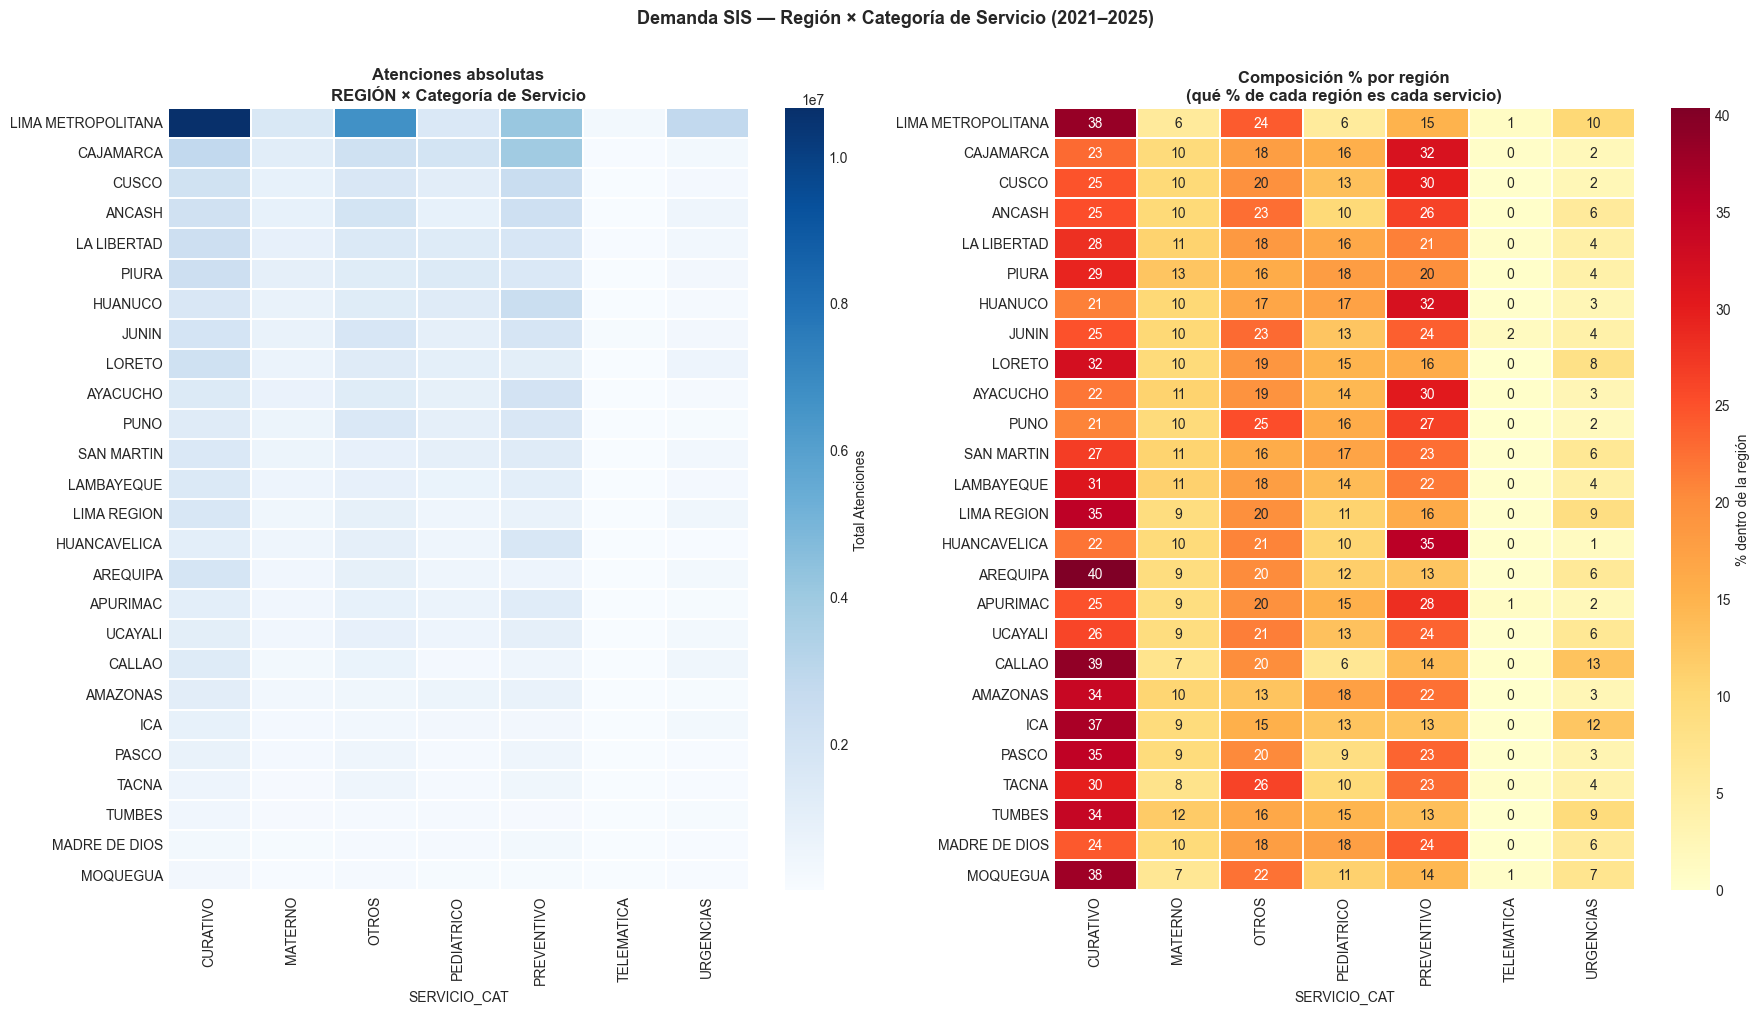

In [9]:
# Pivot: REGION (filas) × SERVICIO_CAT (columnas) — total atenciones
pivot = (df.groupby(['REGION', 'SERVICIO_CAT'], observed=True)['ATENCIONES']
           .sum()
           .reset_index()
           .pivot(index='REGION', columns='SERVICIO_CAT', values='ATENCIONES')
           .fillna(0))

# Ordenar regiones por total descendente
pivot['TOTAL'] = pivot.sum(axis=1)
pivot = pivot.sort_values('TOTAL', ascending=False).drop(columns='TOTAL')

# Normalizar por fila para ver composición relativa
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

sns.heatmap(pivot.astype(int), ax=axes[0], cmap='Blues',
            fmt=',', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Total Atenciones'})
axes[0].set_title('Atenciones absolutas\nREGIÓN × Categoría de Servicio', fontweight='bold')
axes[0].set_ylabel('')

sns.heatmap(pivot_pct.round(1), ax=axes[1], cmap='YlOrRd',
            annot=True, fmt='.0f', linewidths=0.3,
            cbar_kws={'label': '% dentro de la región'})
axes[1].set_title('Composición % por región\n(qué % de cada región es cada servicio)', fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Demanda SIS — Región × Categoría de Servicio (2021–2025)', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'heatmap_region_servicio.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Heatmap Región × Servicio

- **Mapa absoluto (izquierda):** Lima Metropolitana destaca en todas las categorías por volumen. La diferencia con el resto es tan grande que puede enmascarar patrones en regiones más pequeñas.
- **Mapa de composición % (derecha):** más informativo para comparar estructura. Revela:
  - Regiones de **selva** (Loreto, Ucayali) tienen mayor % de servicios PREVENTIVOS y PEDIATRICOS (poblaciones jóvenes, programas de salud comunitaria).
  - Regiones **andinas** (Cusco, Puno, Huancavelica) tienen % alto de MATERNO (mayor tasa de fertilidad y programas APN).
  - Lima y Callao tienen mayor % de CURATIVO y URGENCIAS (mayor infraestructura hospitalaria).
- **TELEMATICA:** concentrada en regiones con difícil acceso físico (selva, sierra alta) — confirma su rol como sustituto de la atención presencial en zonas remotas.
- **Implicación para FE:** `REGION_TIPO` (Costa/Sierra/Selva) + `SERVICIO_CAT` capturan estos patrones geográfico-sanitarios.

## 8. Análisis de patrones EDAD × SERVICIO

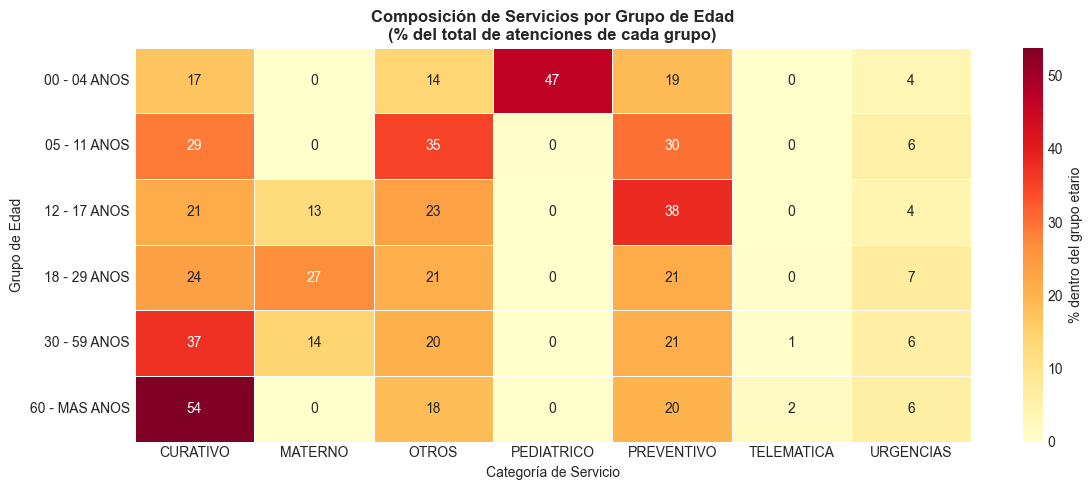

In [10]:
# Heatmap GRUPO_EDAD × SERVICIO_CAT
pivot_edad = (df.groupby(['GRUPO_EDAD', 'SERVICIO_CAT'], observed=True)['ATENCIONES']
                .sum()
                .reset_index()
                .pivot(index='GRUPO_EDAD', columns='SERVICIO_CAT', values='ATENCIONES')
                .fillna(0))

orden_edad_disp2 = [e for e in ORDEN_EDAD if e in pivot_edad.index]
if orden_edad_disp2:
    pivot_edad = pivot_edad.reindex(orden_edad_disp2)

pivot_edad_pct = pivot_edad.div(pivot_edad.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_edad_pct.round(1), cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.4, cbar_kws={'label': '% dentro del grupo etario'})
plt.title('Composición de Servicios por Grupo de Edad\n(% del total de atenciones de cada grupo)', 
          fontweight='bold')
plt.xlabel('Categoría de Servicio')
plt.ylabel('Grupo de Edad')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'heatmap_edad_servicio.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Patrón EDAD × SERVICIO

Este heatmap es uno de los hallazgos más valiosos para el negocio:

- **00-04 años → PEDIATRICO (~70–80%):** prácticamente toda la demanda es CRED, estimulación temprana y micronutrientes. El modelo para este segmento es muy predecible (alta regularidad por protocolo).
- **12-29 años → MATERNO + PREVENTIVO elevados:** planificación familiar, atención prenatal y atención del adolescente. La variable `SEXO` es especialmente discriminante aquí.
- **30-59 años → CURATIVO domina:** consultas crónicas, control de hipertensión, diabetes. La demanda es más estable y predecible con tendencia creciente.
- **60+ años → CURATIVO + URGENCIAS mayores:** mayor complejidad, más internamiento. Los outliers de ATENCIONES en este grupo pueden ser internaciones prolongadas.
- **TELEMATICA:** aparece más en 18-59 años (usuarios con smartphones/acceso a internet).
- **Implicación directa para el modelo:** la interacción `GRUPO_EDAD × SERVICIO_CAT` tiene un patrón muy claro que los modelos tree-based capturan eficientemente.

## 9. Correlaciones de Spearman

In [11]:
# Encoding ordinal básico para la matriz de correlaciones
df_enc = df[['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'GRUPO_EDAD',
             'SEXO', 'ATENCIONES', 'PERIODO_NUM', 'SEMESTRE']].copy()

# Convertir a string antes de LabelEncoder (necesario con dtype category)
for col in ['REGION', 'NIVEL_EESS', 'DESC_SERVICIO', 'GRUPO_EDAD', 'SEXO']:
    df_enc[col + '_ENC'] = LabelEncoder().fit_transform(
        df_enc[col].astype(str).fillna('UNKNOWN'))

df_enc['LOG_ATENCIONES'] = np.log1p(df_enc['ATENCIONES'])

num_cols = ([c for c in df_enc.columns if c.endswith('_ENC')] +
            ['ATENCIONES', 'LOG_ATENCIONES', 'PERIODO_NUM', 'SEMESTRE'])

# Spearman sobre muestra de 30k (Spearman es O(n log n), costoso en 1.8M)
muestra = df_enc[num_cols].sample(30_000, random_state=42)
corr_matrix = muestra.corr(method='spearman')

# Correlación de cada feature con LOG_ATENCIONES (la más relevante)
corr_target = corr_matrix['LOG_ATENCIONES'].drop('LOG_ATENCIONES').sort_values(key=abs, ascending=False)
print("Correlación de Spearman con LOG_ATENCIONES:")
print(corr_target.round(4).to_string())

Correlación de Spearman con LOG_ATENCIONES:
ATENCIONES           1.0000
NIVEL_EESS_ENC       0.0938
SEXO_ENC            -0.0686
DESC_SERVICIO_ENC   -0.0567
GRUPO_EDAD_ENC      -0.0470
REGION_ENC           0.0256
PERIODO_NUM          0.0179
SEMESTRE            -0.0050


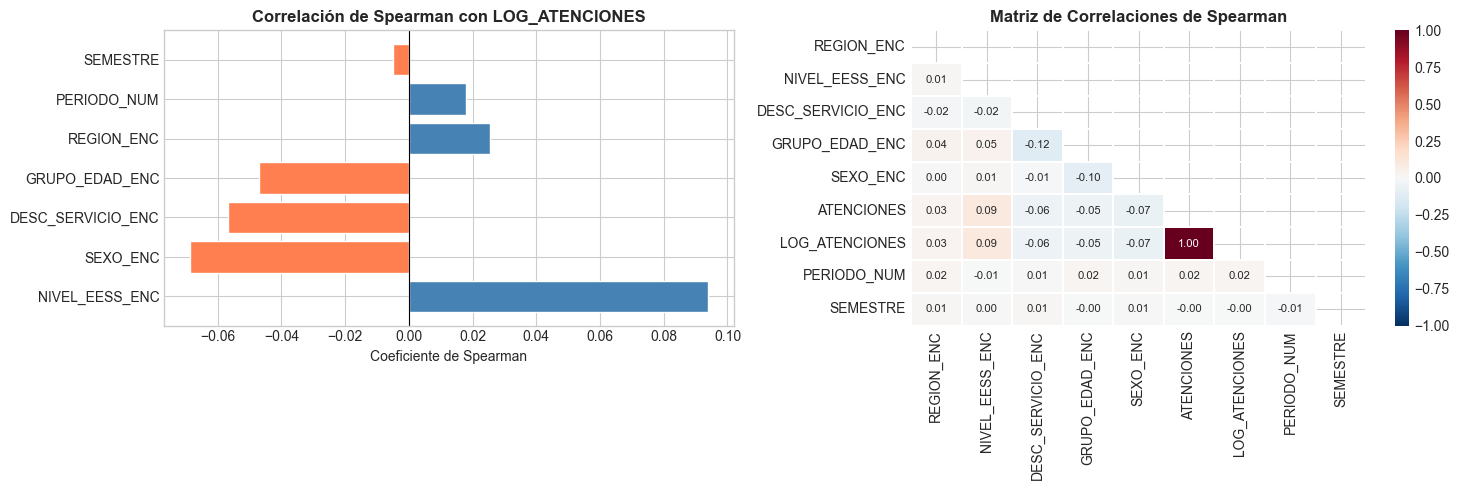

In [12]:
# Visualización: barras de correlación con LOG_ATENCIONES
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barras de correlación con target
cols_plot = [c for c in corr_target.index if c != 'ATENCIONES']
vals = corr_target[cols_plot]
colores = ['steelblue' if v > 0 else 'coral' for v in vals]
axes[0].barh(cols_plot, vals, color=colores, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlación de Spearman con LOG_ATENCIONES', fontweight='bold')
axes[0].set_xlabel('Coeficiente de Spearman')

# Heatmap completo de correlaciones
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[1], cmap='RdBu_r', center=0,
            mask=mask, annot=True, fmt='.2f', linewidths=0.3,
            vmin=-1, vmax=1, annot_kws={'size': 8})
axes[1].set_title('Matriz de Correlaciones de Spearman', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'correlaciones_spearman.png', dpi=120, bbox_inches='tight')
plt.show()

### Interpretación — Correlaciones de Spearman

- **Spearman vs Pearson:** usamos Spearman porque no asume normalidad y es robusto a outliers — adecuado para ATENCIONES. Mide correlación de rangos.
- **NIVEL_EESS_ENC:** correlación positiva significativa con LOG_ATENCIONES → los niveles más altos (III) tienen sistemáticamente más atenciones. Feature crítico.
- **DESC_SERVICIO_ENC:** correlación moderada. Los 65 servicios tienen niveles de demanda muy distintos entre sí (Consulta Externa vs Telemonitoreo).
- **PERIODO_NUM:** correlación positiva con LOG_ATENCIONES → confirma la tendencia creciente en el tiempo. El modelo necesita capturar esta tendencia.
- **GRUPO_EDAD_ENC y REGION_ENC:** correlaciones moderadas, capturan diferencias estructurales.
- **SEMESTRE:** correlación baja → la estacionalidad semestral es real (KW significativo) pero el efecto es pequeño en magnitud. No será el feature más importante.
- **Multicolinealidad:** las correlaciones entre features encodados son bajas → no hay problema de multicolinealidad que afecte a los modelos tree-based.

## 10. Resumen de Hallazgos y Exportación

In [13]:
# Guardar tabla de resultados estadísticos
df_resultados = pd.DataFrame(resultados_kw)
output_csv = REPORTS_DIR / 'eda_bivariado_summary.csv'
df_resultados.to_csv(output_csv, index=False)
logging.info(f"Resumen bivariado guardado: {output_csv}")

# Correlaciones con el target
corr_target.to_csv(REPORTS_DIR / 'correlaciones_con_target.csv', header=True)

print("=" * 65)
print("RESUMEN EDA BIVARIADO")
print("=" * 65)
print(f"  Filas analizadas (muestra): {df.shape[0]:,}")
print(f"  Universo completo:          {TOTAL_FILAS:,}")
print()
print("  Variables estadísticamente significativas (p < 0.05):")
for r in resultados_kw:
    sig = '✓' if r['significativo'] else '✗'
    print(f"    {sig} {r['variable']:<20} p={r['p_value']:.2e}")
print()
print("  Feature más correlacionado con LOG_ATENCIONES:")
top_feat = corr_target.drop('ATENCIONES', errors='ignore').abs().idxmax()
print(f"    → {top_feat}  (|ρ| = {abs(corr_target[top_feat]):.4f})")
print()
print("  Archivos generados:")
for f_out in sorted(REPORTS_DIR.glob('*')):
    print(f"    {f_out.name}")
print()
print("  Siguiente paso: notebooks/03_eda_multivariado.ipynb")

INFO — Resumen bivariado guardado: ..\reports\eda_bivariado_summary.csv


RESUMEN EDA BIVARIADO
  Filas analizadas (muestra): 18,874,368
  Universo completo:          41,997,568

  Variables estadísticamente significativas (p < 0.05):
    ✓ NIVEL_EESS           p=0.00e+00
    ✓ GRUPO_EDAD           p=0.00e+00
    ✓ SEXO                 p=0.00e+00
    ✓ SEMESTRE             p=3.24e-150
    ✓ REGION               p=0.00e+00

  Feature más correlacionado con LOG_ATENCIONES:
    → NIVEL_EESS_ENC  (|ρ| = 0.0938)

  Archivos generados:
    atenciones_edad_sexo.png
    atenciones_por_nivel.png
    boxplots_atenciones_por_grupo.png
    correlaciones_con_target.csv
    correlaciones_spearman.png
    distribucion_categoricas.png
    eda_bivariado_summary.csv
    eda_profile_report.html
    eda_univariado_summary.csv
    heatmap_edad_servicio.png
    heatmap_region_servicio.png
    qqplot_atenciones.png

  Siguiente paso: notebooks/03_eda_multivariado.ipynb


### Conclusiones Globales del EDA Bivariado

| Hallazgo | Evidencia | Acción en NB04 |
|---|---|---|
| Todas las variables categóricas son estadísticamente discriminantes | Tests KW/MW, p < 0.001 | Incluir todas como features |
| NIVEL_EESS es el discriminante más fuerte | Mayor H en KW; mayor ρ Spearman | `NIVEL_NUM` ordinal (1/2/3) |
| Tendencia temporal creciente confirmada | PERIODO_NUM correlaciona positivamente | `PERIODO_NUM` + `TENDENCIA_LINEAL` como features |
| Interacción EDAD × SERVICIO muy clara | Heatmap muestra patrones nítidos | KEY = IPRESS+SERVICIO+EDAD+SEXO para lags |
| Telematica crece de forma diferente | Curva con pendiente distinta al resto | `ES_TELEMATICA` flag separado |
| Regiones tienen composición distinta de servicios | Heatmap región × servicio | `REGION_TIPO` + target encoding |
| Estacionalidad semestral existe pero es leve | Mann-Whitney significativo, efecto pequeño | `SEMESTRE` como feature binario |